In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm


   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training

Размер датасета: (35887, 3)

Распределение эмоций:
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


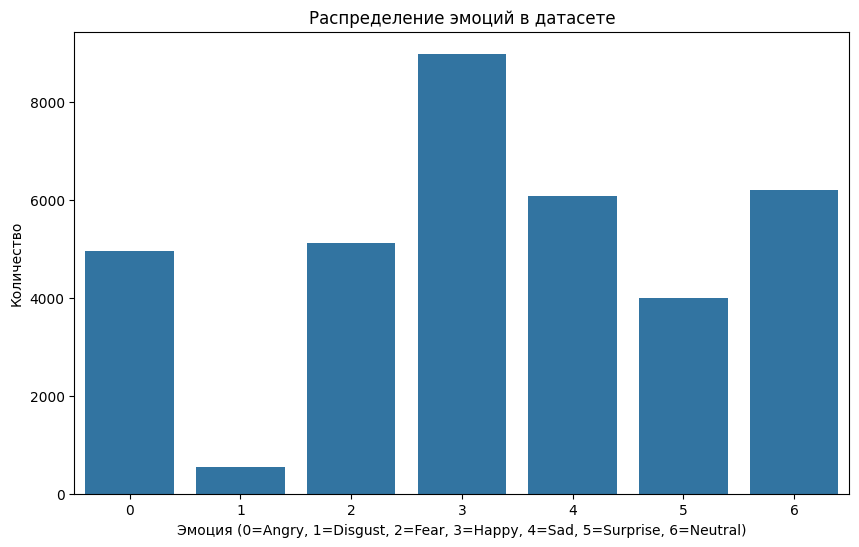

In [3]:
# Загрузка данных
df = pd.read_csv('fer2013.csv')

# Просмотр первых строк
print(df.head())
print(f"\nРазмер датасета: {df.shape}")
print(f"\nРаспределение эмоций:\n{df['emotion'].value_counts()}")

# Визуализация распределения классов
plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=df)
plt.title('Распределение эмоций в датасете')
plt.xlabel('Эмоция (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral)')
plt.ylabel('Количество')
plt.show()

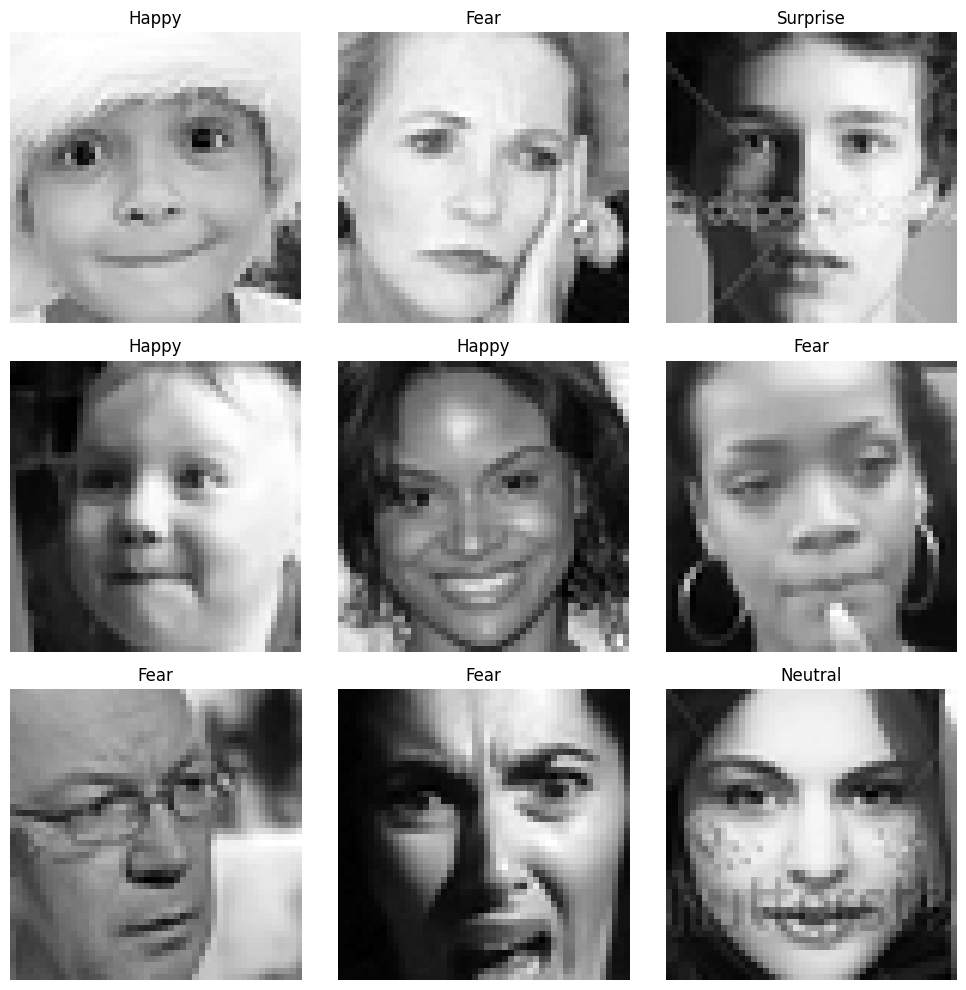

In [4]:
# Словарь меток эмоций
emotion_labels = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 
                  4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Функция для отображения изображений
def show_images(df, num_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()
    
    for i in range(num_images):
        # Берём случайную строку
        idx = np.random.randint(0, len(df))
        pixels = df.iloc[idx]['pixels']
        emotion = df.iloc[idx]['emotion']
        
        # Преобразуем строку пикселей в массив
        img = np.array([int(p) for p in pixels.split()]).reshape(48, 48)
        
        # Отображаем
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{emotion_labels[emotion]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_images(df)


In [5]:
class FER2013Dataset(Dataset):
    """Класс для загрузки датасета FER2013"""
    
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Получаем пиксели и метку
        pixels = self.df.iloc[idx]['pixels']
        emotion = self.df.iloc[idx]['emotion']
        
        # Преобразуем строку пикселей в numpy массив 48x48
        image = np.array([int(p) for p in pixels.split()]).reshape(48, 48).astype('float32')
        
        # Нормализация (0-255 -> 0-1)
        image = image / 255.0
        
        # Добавляем канал (1, 48, 48) для grayscale
        image = np.expand_dims(image, axis=0)
        
        # Преобразуем в torch tensor
        image = torch.from_numpy(image)
        
        # Применяем трансформации (если есть)
        if self.transform:
            image = self.transform(image)
        
        return image, emotion

# Тестируем класс
sample_dataset = FER2013Dataset(df)
sample_image, sample_label = sample_dataset[0]
print(f"Размер изображения: {sample_image.shape}")
print(f"Метка эмоции: {sample_label}")


Размер изображения: torch.Size([1, 48, 48])
Метка эмоции: 0


In [6]:
# Разделяем на train и test (80% / 20%)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])

# Из train выделяем validation (80% train / 20% validation)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['emotion'])

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Создаём Dataset и DataLoader
train_dataset = FER2013Dataset(train_df)
val_dataset = FER2013Dataset(val_df)
test_dataset = FER2013Dataset(test_df)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Train: 22967, Validation: 5742, Test: 7178


In [7]:
class EmotionCNN(nn.Module):
    """Сверточная нейросеть для распознавания эмоций"""
    
    def __init__(self):
        super(EmotionCNN, self).__init__()
        
        # Первый сверточный блок
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Второй сверточный блок
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Третий сверточный блок
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Полносвязные слои
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 7)  # 7 классов эмоций
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Первый блок
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        # Второй блок
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        # Третий блок
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Полносвязные слои
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        
        return x

# Создаём модель
model = EmotionCNN()
print(model)

# Проверяем работу модели на одном батче
sample_batch, _ = next(iter(train_loader))
output = model(sample_batch)
print(f"\nРазмер выхода модели: {output.shape}")  # Должно быть (batch_size, 7)


EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=7, bias=True)
  (relu): ReLU()
)

Размер выхода модели: torch.Size([64, 7])


In [9]:
# Проверяем наличие GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Переносим модель на device
model = model.to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler для уменьшения learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)


Используется устройство: cpu


In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Обучение модели на одной эпохе"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        # Обнуляем градиенты
        optimizer.zero_grad()
        
        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Обратный проход
        loss.backward()
        optimizer.step()
        
        # Статистика
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """Валидация модели"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


In [12]:
num_epochs = 30
train_losses, train_accs = [], []
val_losses, val_accs = [], []

best_val_acc = 0.0

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch+1}/{num_epochs}")
    
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Валидация
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/emotion_model_our_architecture.pth')
        print("✓ Модель сохранена!")
    
    # Обновляем learning rate
    scheduler.step(val_loss)

print(f"\nЛучшая точность на валидации: {best_val_acc:.2f}%")



Эпоха 1/30


Validation: 100%|██████████| 90/90 [00:03<00:00, 27.59it/s]


Train Loss: 1.5367, Train Acc: 40.12%
Val Loss: 1.4406, Val Acc: 43.75%
✓ Модель сохранена!

Эпоха 2/30


Validation: 100%|██████████| 90/90 [00:03<00:00, 27.44it/s]


Train Loss: 1.4598, Train Acc: 43.11%
Val Loss: 1.3919, Val Acc: 46.78%
✓ Модель сохранена!

Эпоха 3/30


...

Train Loss: 0.5363, Train Acc: 77.42%
Val Loss: 1.6726, Val Acc: 56.84%

Эпоха 29/30


Validation: 100%|██████████| 90/90 [00:03<00:00, 27.97it/s]


Train Loss: 0.5309, Train Acc: 78.01%
Val Loss: 1.6969, Val Acc: 57.04%

Эпоха 30/30


Validation: 100%|██████████| 90/90 [00:03<00:00, 27.19it/s]

Train Loss: 0.5136, Train Acc: 78.59%
Val Loss: 1.7398, Val Acc: 57.35%

Лучшая точность на валидации: 57.45%


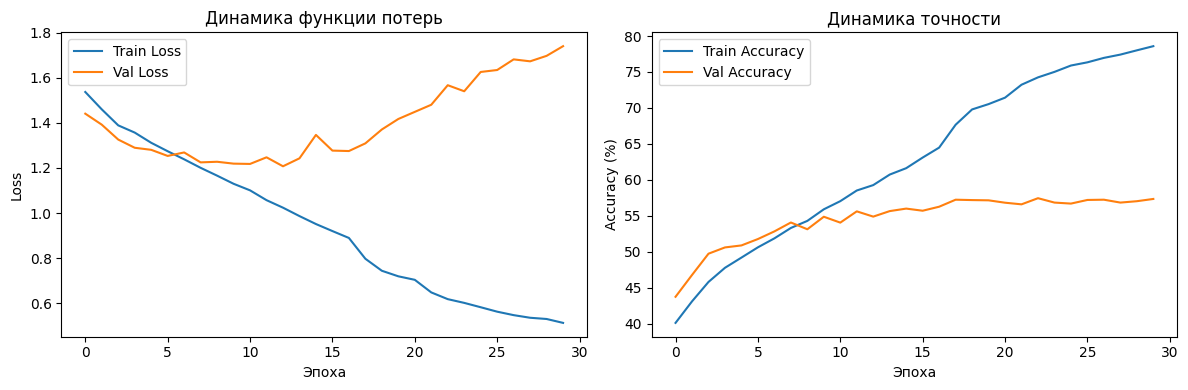

In [13]:
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.title('Динамика функции потерь')

# График точности
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Динамика точности')

plt.tight_layout()
plt.show()